# **1. 서울 자전거 공유 수요 데이터셋**

서울시의 공공자전거 대여 서비스인 ‘따릉이’의 대여 수요를 예측하는 문제에 사용되는 데이터셋입니다. 특정 시간대와 날씨, 요일, 공휴일 여부, 기온, 습도 등 다양한 데이터를 활용하여 자전거 대여 수요를 예측합니다.

# 2. 데이터셋 컬럼
- Date : 연월일
- Rented Bike count - 매 시간마다 대여한 자전거 수
- Hour - 하루 중 시간
- Temperature - 온도
- Humidity - 습도 %
- Windspeed - 풍속 m/s
- Visibility - 가시거리 m
- Dew point temperature - 이슬점 온도
- Solar radiation - 태양 복사 MJ/m2
- Rainfall - 강우량 mm
- Snowfall - 적설량 cm
- Seasons - 겨울, 봄, 여름, 가을
- Holiday - 휴일/휴일 없음
- Functional Day - 운영되지 않았던 날, 정상적으로 운영된 날

In [1]:
import pandas as pd
from pathlib import Path

### ※ CP949
- Microsoft Windows의 한국어 문자 인코딩입니다.
- EUC-KR을 확장한 형태로, 더 많은 한국어 문자(한자, 확장 문자 등)를 지원합니다.
- 주로 Windows 환경에서 저장된 한글 파일에서 사용됩니다.-

In [3]:
DATA_PATH = Path('./data/SeoulBikeData.csv')
bike_raw = pd.read_csv(DATA_PATH, encoding='CP949')
bike_raw


,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# **3. 데이터 전처리 및 탐색적 데이터 분석 (EDA)**

Exploratory Data Analysis의 약자로 데이터를 본격적으로 모델링하거나 가설을 검증하기 전에 데이터의 구조, 특성, 패턴, 이상치, 변수 간의 관계를 이해하는 과정

### 1. EDA의 목적
- 데이터의 전체적인 구조 파악
- 결측치 확인
- 이상치 탐색
- 변수의 분포 확인
- 변수 간 관계 분석
- 데이터 품질 문제 발견
- 모델링 전에 전처리 방향 결정
- 새로운 가설 생성

### 2. EDA의 전체 과정
1. 데이터 불러오기
2. 데이터 구조 확인
3. 기초 통계 확인
4. 결측치 확인
5. 이상치 확인
6. 단변량 분석 (변수 하나에 값이 어떻게 들어있는지 분석)
7. 다변량 분석
8. 시각화
9. 인사이트 도출
10. 전처리 방향 결정

In [4]:
bike_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [5]:
bike_raw.describe() # 이상치 있나

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
bike_raw.describe(include='str')

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


In [8]:
bike_raw.describe(include='all')

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,01/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


In [9]:
bike_df = bike_raw.copy()

In [10]:
bike_df.columns = [
    'Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
    'Wind speed', 'Visibility', 'Dew point temperature',
    'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons',
    'Holiday', 'Functioning Day'
]

In [11]:
quality_report = pd.DataFrame({
    'missing_count': bike_df.isna().sum(),
    'missing_ratio': bike_df.isna().mean(),
    'nunique': bike_df.nunique()
})
print(quality_report)

                       missing_count  missing_ratio  nunique
Date                               0            0.0      365
Rented Bike Count                  0            0.0     2166
Hour                               0            0.0       24
Temperature                        0            0.0      546
Humidity                           0            0.0       90
Wind speed                         0            0.0       65
Visibility                         0            0.0     1789
Dew point temperature              0            0.0      556
Solar Radiation                    0            0.0      345
Rainfall                           0            0.0       61
Snowfall                           0            0.0       51
Seasons                            0            0.0        4
Holiday                            0            0.0        2
Functioning Day                    0            0.0        2


In [12]:
# 중복행
bike_raw.duplicated().sum()

np.int64(0)

### 3. 날짜 처리와 피처 엔지니어링
- Date는 문자열 그대로 모델에 넣을 수 없음
- 날짜를 여러 의미있는 변수로 나눔
    - year, month, day, dayofweek, is_weekend
    - hours_sin, hours_cos: 23시와 0시가 가깝다는 것을 모델에 알려주는 주기형 인코딩
    - month_sin, month_cos: 12월 1월이 가깝다는 것을 모델에 알려주는 주기형 인코딩

In [14]:
# 일/월/년
bike_df['Date'] = pd.to_datetime(bike_df['Date'], format = '%d/%m/%Y')
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [22]:
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day
bike_df['dayofweek'] = bike_df['Date'].dt.dayofweek
bike_df['is_weekend'] = bike_df['dayofweek'].isin([5, 6]).astype(int)
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,year,month,day,dayofweek,is_weekend,hours_sin,hours_cos,month_sin,month_cos,month
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.000000,1.000000,0.000000,0.000000,12
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.258819,0.965926,0.500000,0.500000,12
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,2017,12,1,4,0,0.500000,0.866025,0.866025,0.866025,12
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.707107,0.707107,1.000000,1.000000,12
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,2017,12,1,4,0,0.866025,0.500000,0.866025,0.866025,12


- 시간과 월은 반복되는 순환 구조
- 머신러닝의 이해: 0 < 1 < 2 < ...< 23
- 사람: 23<0<1 .. (순환)
- np.pi * 2 * bike_df['Hour'] / 24 : 시간을 각도로 변환
- sin: 원에서 y좌표를 의미(0, 1) (1, 0), (0, 1), (-1, 0) / 1 > 0 > -1 > 0 > 1 ...
-   # 6시: 1, 18시: -1, 30도: 0.5, 150도 0.5
- cos: 원에서 x좌표를 의미(0, 1) (1, 0), (0, 1), (-1, 0) / 1 > 0 > -1 > 0 > 1 ...
> sin만 사용하면 같은 sin값을 가질 수 있는 시간이 생김. cos까지 사용하면 원 위치가 완벽하게 결정


```
시간    각도    sin     cos
0시     0       0       1
6시     90      1       0
12시    180     0       -1
18시    270     -1      0
24시    360     0       1
```

In [16]:
import numpy as np

In [23]:
# 시간
bike_df['hours_sin'] = np.sin(2 * np.pi * bike_df['Hour'] / 24)
bike_df['hours_cos'] = np.cos(2 * np.pi * bike_df['Hour'] / 24)

# 월
bike_df['month_sin'] = np.sin(2 * np.pi * bike_df['month'] / 12)
bike_df['month_cos'] = np.cos(2 * np.pi * bike_df['month'] / 12)

bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,year,month,day,dayofweek,is_weekend,hours_sin,hours_cos,month_sin,month_cos,month
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.000000,1.000000,-2.449294e-16,1.0,12
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.258819,0.965926,-2.449294e-16,1.0,12
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,2017,12,1,4,0,0.500000,0.866025,-2.449294e-16,1.0,12
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,2017,12,1,4,0,0.707107,0.707107,-2.449294e-16,1.0,12
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,2017,12,1,4,0,0.866025,0.500000,-2.449294e-16,1.0,12


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
plt.rcParams['font.family'] = 'Malgun Gothic'

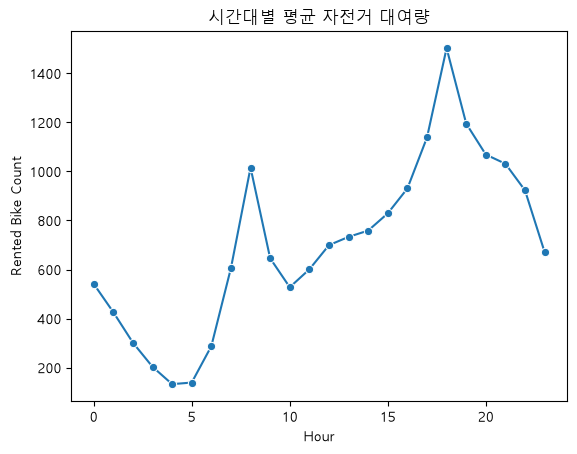

In [29]:
# 시간대별 평군 대여량
hourly_demand = bike_df.groupby('Hour')['Rented Bike Count'].mean().reset_index()
sns.lineplot(data = hourly_demand, x='Hour', y = 'Rented Bike Count', marker = 'o')
plt.title('시간대별 평균 자전거 대여량')
plt.show()

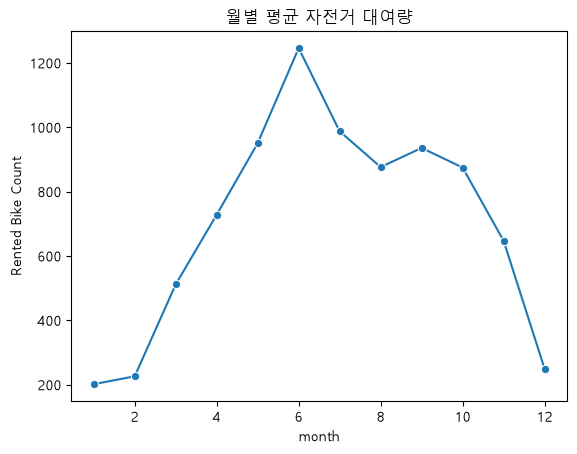

In [30]:
# 월별 평균 대여량
monthly_demand = bike_df.groupby('month')['Rented Bike Count'].mean().reset_index()
sns.lineplot(data = monthly_demand, x='month', y = 'Rented Bike Count', marker = 'o')
plt.title('월별 평균 자전거 대여량')
plt.show()

### Seaborn의 barplot
- 막대: 막대의 높이는 기본적으로 평균. x축(또는 y축)에 있는 각 범주(category) 별로 y값(수치형)의 평균을 계산해서 그 평균을 막대 높이로 그림. 막대가 높다는 것은 그 범주의 평균이 높다는 뜻
- 막대기리 비교할 때는 "차이의 크기"를 봄
    - A 막대가 B보다 높다 > A의 평균이 더 크다
    - 막대 차이가 크다 > 집단 간 평균 차이가 크다
    - 비슷하다 > 큰 차이가 없다(평균 관점): 평균이 비슷해도 데이터가 다를 수 
- 에러바(아래 막대 그래프의 검은 선): 평균이 얼마나 믿을 만한지 또는 흔들리는지를 표현하는 바. 데이터를 기반으로 유사한 100가지의 케이스에서 95개 이상은 해당 범위에서 결과를 얻음을 의미 > 평균/중앙값/최빈값 등의 다른 값들을 함께 고려한 신뢰성 있는 수치(바가 길수록 데이터가 없어서 신뢰성이 떨어진다는 의미)

In [ ]:
# 계절/공휴일/운영일별 평균 대여량

for col in ['Seasons', 'Holiday', 'Functioning Day']:
    sns.barplot(data=bike_df, x = col, y = 'Rented Bike Count')
    plt.title(f"{col}별 평균 자전거 대여량")
    plt.xticks(rotation = 20)
    plt.show()

In [ ]:
plt.rcParams['axes.unicode_minus'] = False

c:\heeseung\10_MLDL\venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


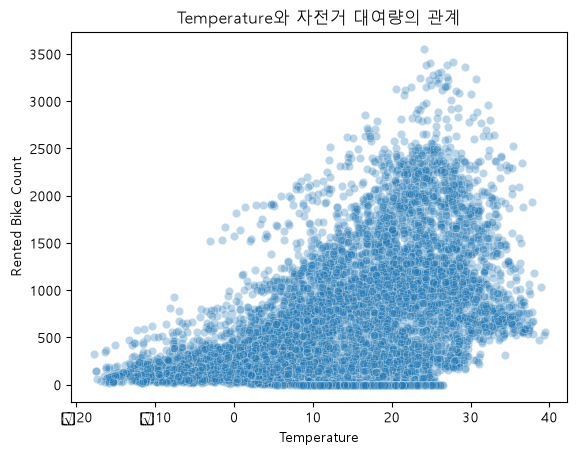

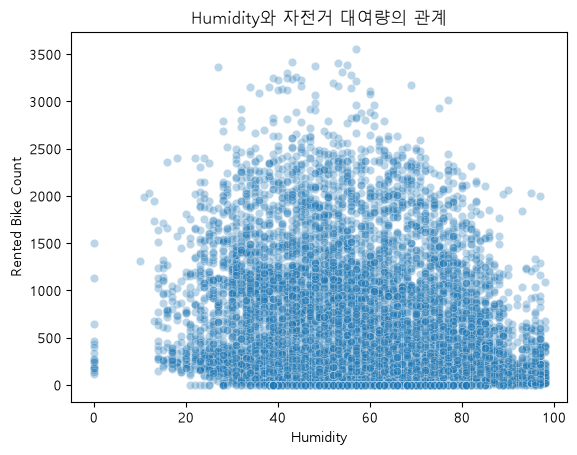

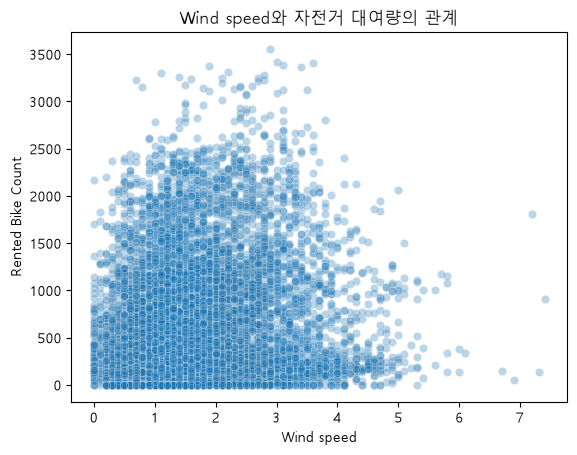

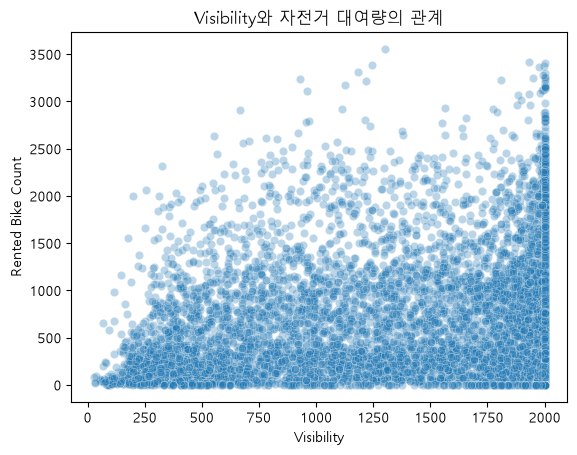

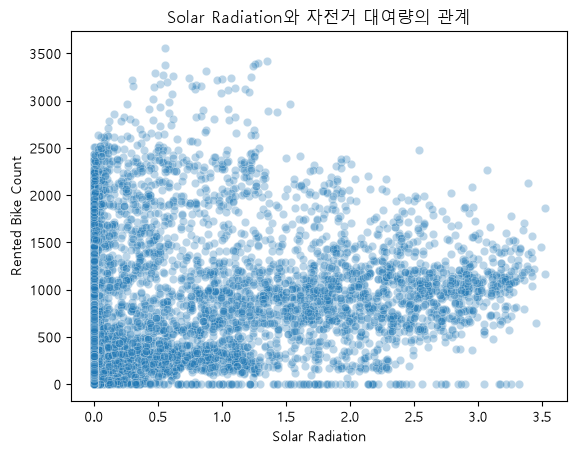

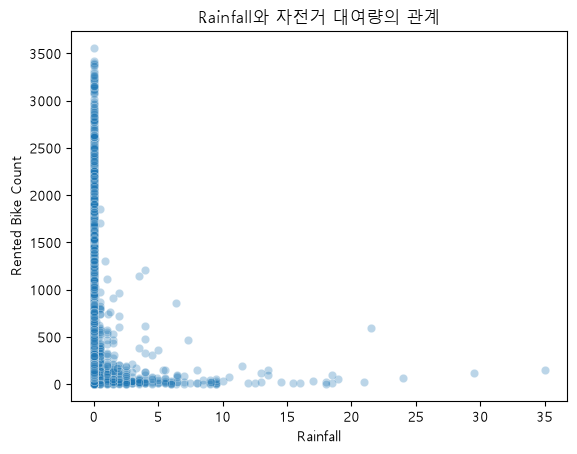

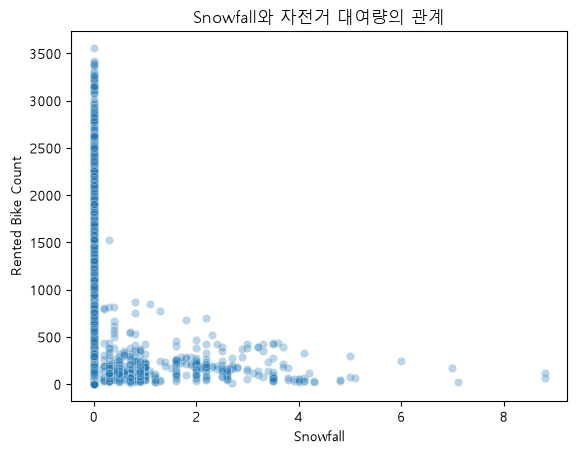

In [32]:
# 날씨 변수와 대여량 관계
weather_cols = ['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall']

for col in weather_cols:
    sns.scatterplot(data=bike_df, x=col, y='Rented Bike Count', alpha=0.3)
    plt.title(f'{col}와 자전거 대여량의 관계')
    plt.show()

### 운영일 데이터만 사용

In [35]:
model_df = bike_df[bike_df['Functioning Day'] == 'Yes'].copy()
model_df = model_df.drop(columns=['Functioning Day'])
print('전체 데이터 크기: ', bike_df.shape)
print('운영일 데이터 크기: ', model_df.shape)

전체 데이터 크기:  (8760, 24)
운영일 데이터 크기:  (8465, 23)


### 학습/검증 데이터 분할

- 시간 기준 분할: 랜덤 분할은 미래 시점의 데이터가 학습 데이터에 섞일 수 있음. 수요 예측은 보통 과거를 보고 미래를 예츨해야 하므로 시간 순서 기준 검증이 더 자연스러움

In [36]:
target = 'Rented Bike Count'
model_df = model_df.sort_values(['Date', 'Hour']).reset_index(drop=True)
feature_cols = [col for col in model_df.columns if col not in [target, 'Date']]

X = model_df[feature_cols]
y = model_df[target]

In [37]:
split_idx = int(len(model_df) * 0.8)
split_idx

6772

In [42]:
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print('학습 데이터: ', X_train.shape, y_train.shape)
print('테스트 데이터: ', X_test.shape, y_test.shape)
print('학습 기간: ', model_df.loc[:split_idx-1, 'Date'].min(), model_df.loc[:split_idx-1,'Date'].max())
print('테스트 기간: ', model_df.loc[:split_idx, 'Date'].min(), model_df.loc[:split_idx,'Date'].max())
# print('학습 기간: ', model_df.loc[:split_idx,])

학습 데이터:  (6772, 21) (6772,)
테스트 데이터:  (1693, 21) (1693,)
학습 기간:  2017-12-01 00:00:00 2018-09-11 00:00:00
테스트 기간:  2017-12-01 00:00:00 2018-09-11 00:00:00
